# 01 — Perfil Demográfico e Geográfico

**Objetivo**: analisar distribuição das variáveis demográficas e geográficas dos municípios.

**Inputs**: `data/processed/trusted_municipios_eda.parquet`.

**Outputs**: figuras demográficas e tabela resumo por região.

In [1]:
# Imports
import logging

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import PROCESSED_DATA_DIR
from src.utils.eda import (
    compute_descriptive_stats,
    plot_boxplot_by_group,
    plot_distribution,
    plot_correlation_heatmap,
    save_figure,
    save_json,
)

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
# Leitura
df = pd.read_parquet(PROCESSED_DATA_DIR / "trusted_municipios_eda.parquet")
logger.info("Linhas: %d, Colunas: %d", df.shape[0], df.shape[1])

2026-09-03 12:11:05,117 - INFO - Linhas: 5570, Colunas: 32


## 1. Estatísticas descritivas das variáveis demográficas

In [3]:
demo_cols = [
    "populacao_total",
    "populacao_18_35_pct",
    "populacao_urbana_pct",
    "escolaridade_ensino_medio_pct",
    "idhm",
]
desc = compute_descriptive_stats(df[demo_cols])
display(desc)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skewness,kurtosis,iqr,missing_pct
populacao_total,5570.0,36459.740754,206518.731949,833.000000,1687.760000,2458.450000,5228.000000,11065.000000,24427.250000,111869.700000,418368.570000,1.145200e+07,37.180725,1838.969646,19199.250000,0.00
populacao_18_35_pct,5570.0,25.669324,2.890479,14.358974,18.704506,20.848177,23.840321,25.759947,27.497317,30.145708,32.452789,5.058185e+01,0.143247,1.734782,3.656996,0.00
populacao_urbana_pct,5570.0,69.038879,20.137436,7.330868,22.116393,33.775194,54.114315,70.834550,86.051042,97.446836,99.848755,1.000000e+02,-0.385310,-0.724555,31.936726,0.00
escolaridade_ensino_medio_pct,5570.0,39.514121,9.389178,13.609996,22.185273,25.902718,32.663914,38.535468,45.241462,56.749947,64.758012,7.795334e+01,0.540672,0.162450,12.577548,0.00
idhm,5564.0,0.659168,0.072000,0.418000,0.506630,0.544000,0.599000,0.665000,0.718000,0.766000,0.795000,8.620000e-01,-0.155956,-0.844371,0.119000,0.11


## 2. Distribuições

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


2026-09-03 12:11:06,181 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/01_dist_populacao_total.png


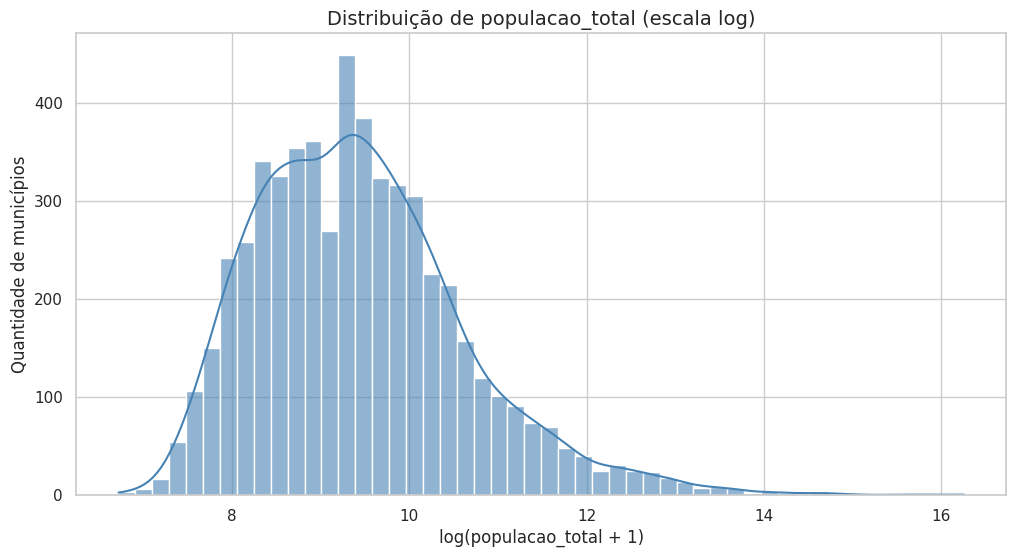

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


2026-09-03 12:11:07,722 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/01_dist_populacao_18_35_pct.png


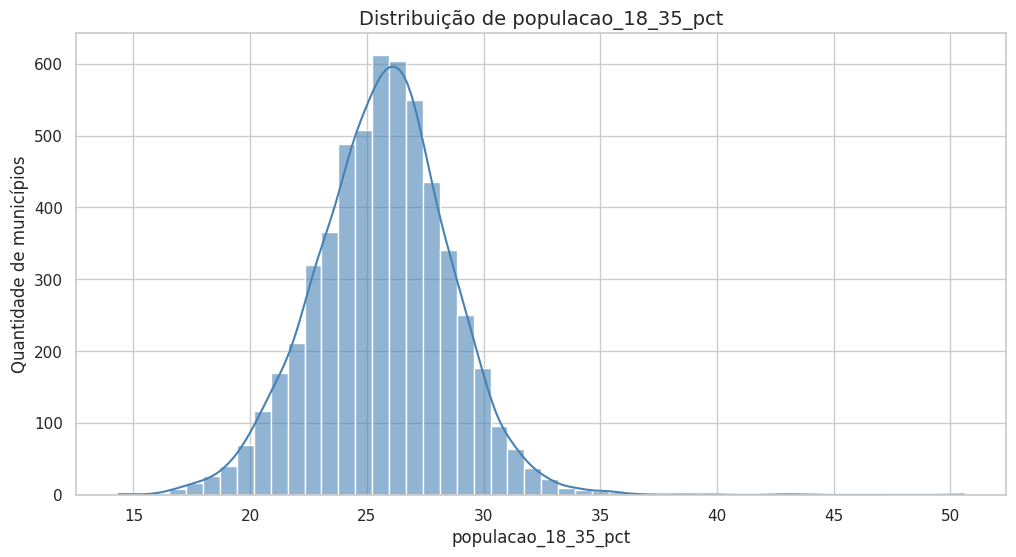

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


2026-09-03 12:11:09,262 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/01_dist_populacao_urbana_pct.png


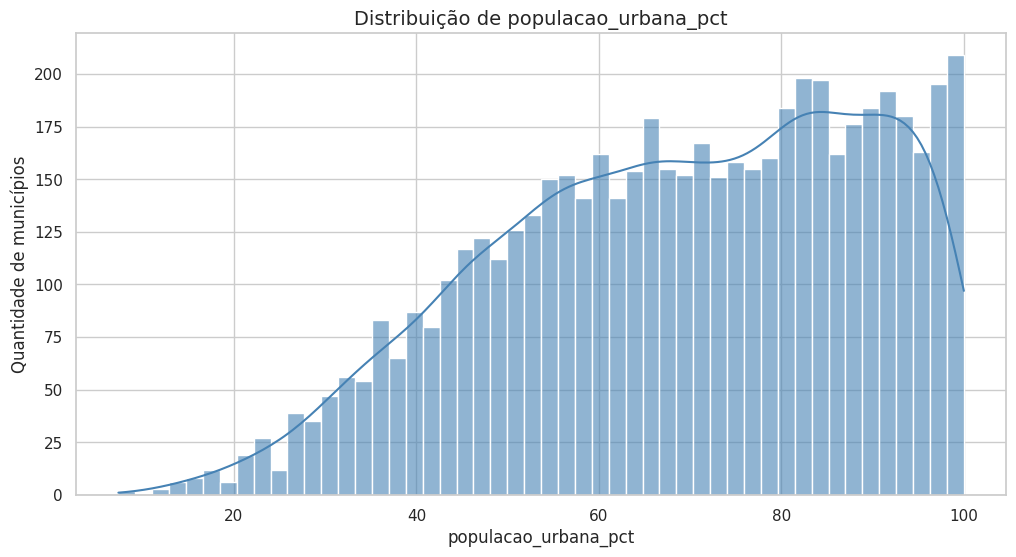

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


2026-09-03 12:11:10,996 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/01_dist_escolaridade_ensino_medio_pct.png


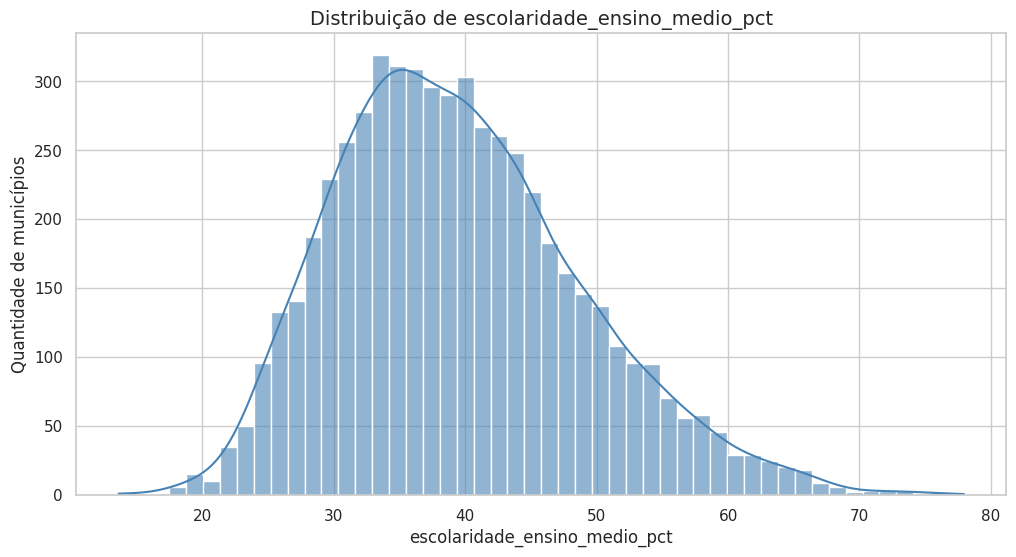

In [4]:
plot_distribution(
    df, "populacao_total", log_scale=True, filename="01_dist_populacao_total.png"
)
plt.show()

for col in [
    "populacao_18_35_pct",
    "populacao_urbana_pct",
    "escolaridade_ensino_medio_pct",
]:
    plot_distribution(df, col, filename=f"01_dist_{col}.png")
    plt.show()

## 3. Boxplots por região

2026-09-03 12:11:12,332 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/01_boxplot_escolaridade_ensino_medio_pct_regiao.png


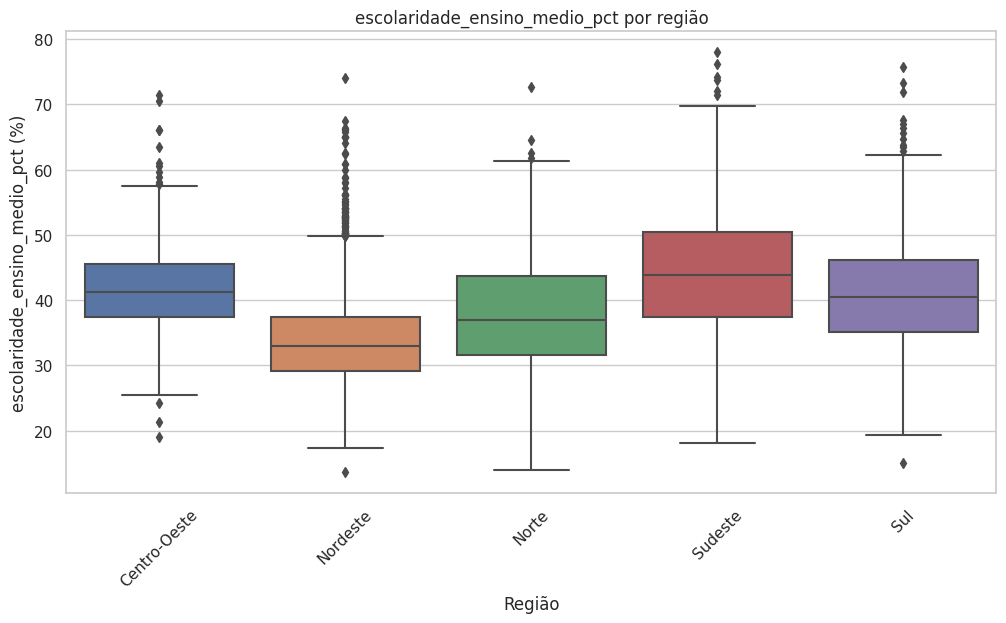

2026-09-03 12:11:13,475 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/01_boxplot_populacao_18_35_pct_regiao.png


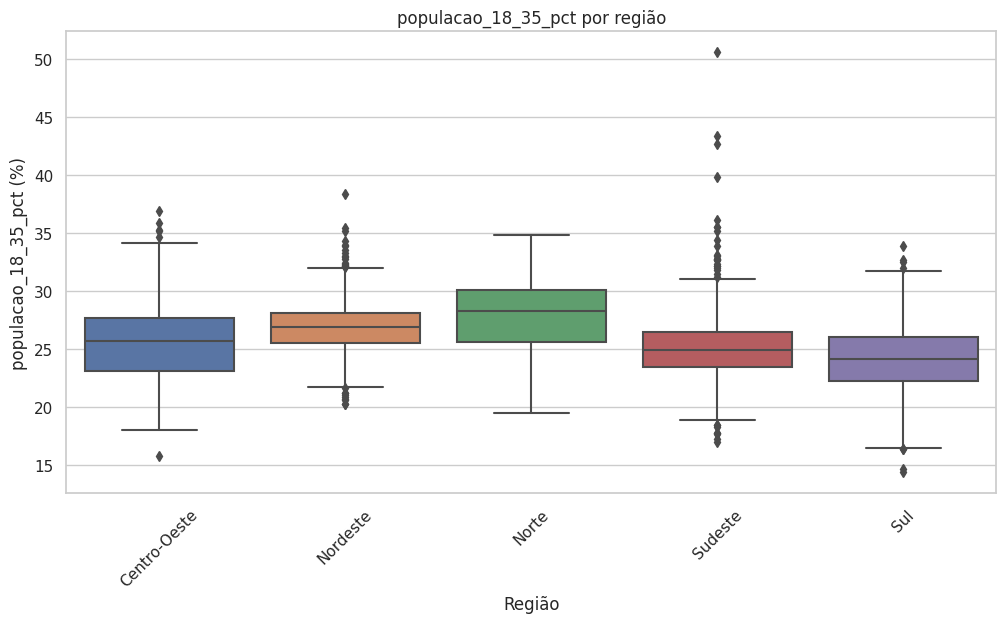

2026-09-03 12:11:14,447 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/01_boxplot_populacao_urbana_pct_regiao.png


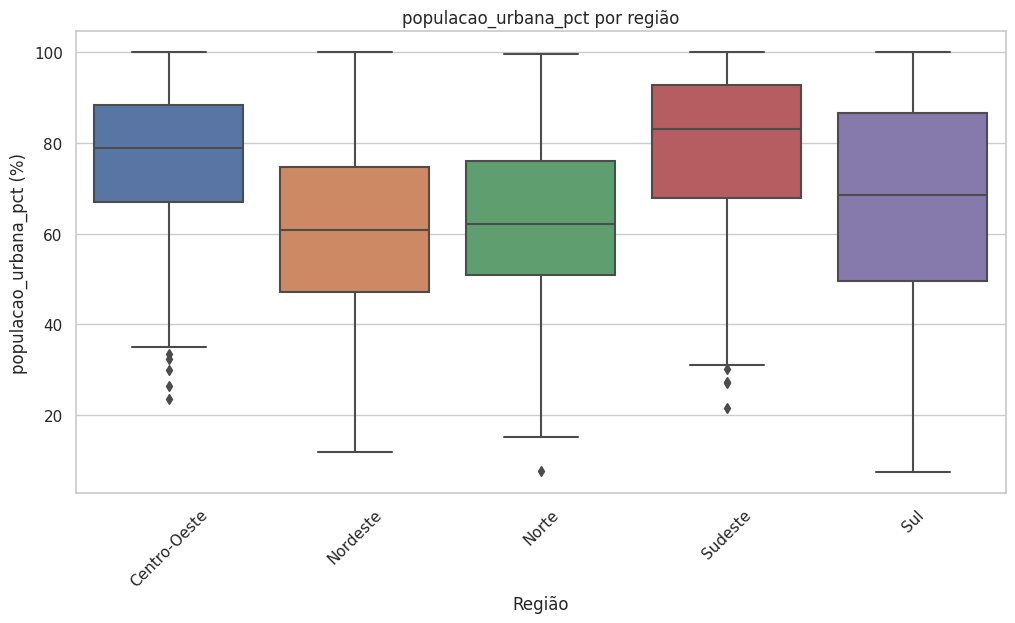

In [5]:
# Boxplots demográficos por região
for col in ["escolaridade_ensino_medio_pct", "populacao_18_35_pct", "populacao_urbana_pct"]:
    unidade = "%"
    plot_boxplot_by_group(
        df,
        col,
        "nome_regiao",
        title=f"{col} por região",
        xlabel="Região",
        ylabel=f"{col} ({unidade})",
        filename=f"01_boxplot_{col}_regiao.png",
    )
    plt.show()


### Perfil médio por região: população jovem e urbanização

Barras agrupadas comparando a proporção média de população jovem (18–35 anos) e de população urbana por região. Os achados de urbanização e de população jovem por região (relatório, seção 4) ganham aqui uma visualização direta: **1.098 municípios** combinam simultaneamente perfil jovem, urbano e escolarizado acima da mediana (seção 6 deste notebook).

2026-09-03 12:11:16,166 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/01_perfil_regiao_barras.png


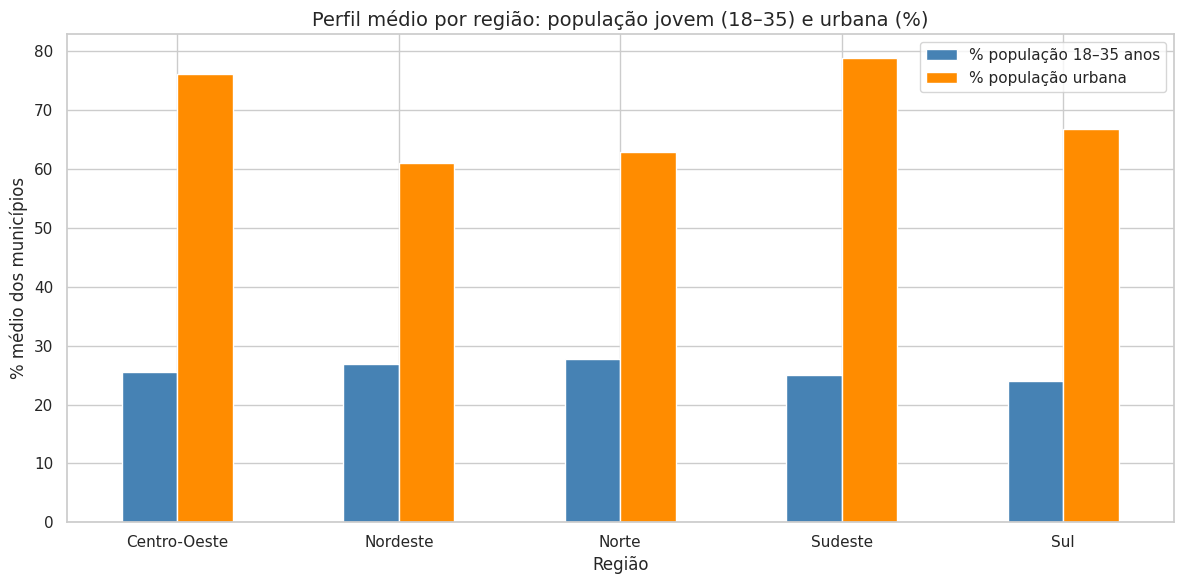

In [6]:
# Barras agrupadas: % população 18-35 e % urbana por região
perfil_regiao = (
    df.groupby("nome_regiao")[["populacao_18_35_pct", "populacao_urbana_pct"]]
    .mean()
    .round(2)
)

fig, ax = plt.subplots(figsize=(12, 6))
perfil_regiao.plot(kind="bar", ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Perfil médio por região: população jovem (18–35) e urbana (%)", fontsize=14)
ax.set_xlabel("Região", fontsize=12)
ax.set_ylabel("% médio dos municípios", fontsize=12)
ax.tick_params(axis="x", rotation=0)
ax.legend(["% população 18–35 anos", "% população urbana"])
plt.tight_layout()
save_figure(fig, "01_perfil_regiao_barras.png")
plt.show()

## 4. Correlação entre variáveis demográficas

2026-09-03 12:11:17,832 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/01_correlacao_demografica.png


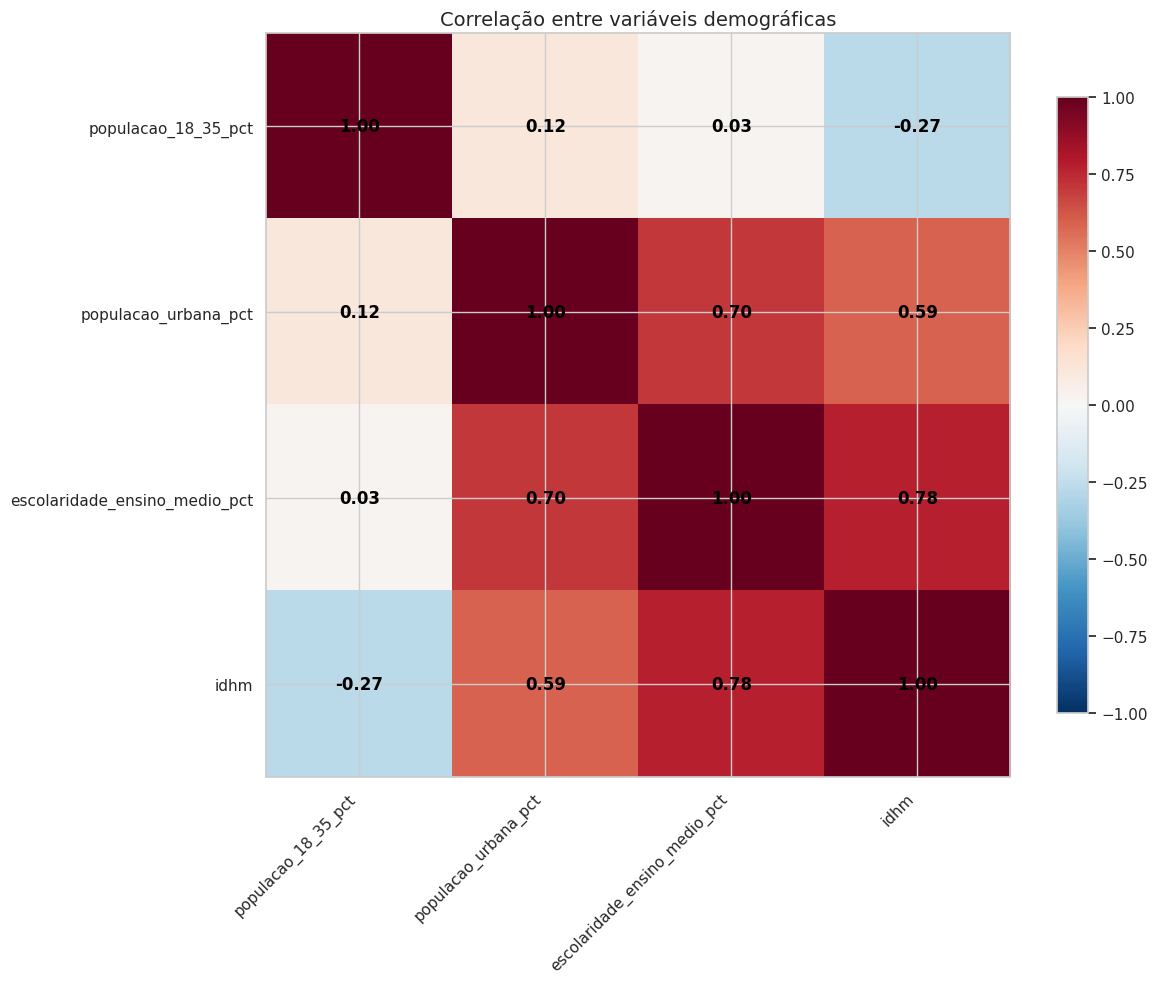

In [7]:
plot_correlation_heatmap(
    df,
    ["populacao_18_35_pct", "populacao_urbana_pct", "escolaridade_ensino_medio_pct", "idhm"],
    method="spearman",
    title="Correlação entre variáveis demográficas",
    filename="01_correlacao_demografica.png",
)
plt.show()

## 5. Tabela resumo por região

In [8]:
resumo_regiao = (
    df.groupby("nome_regiao")[demo_cols]
    .mean()
    .round(2)
    .sort_values("escolaridade_ensino_medio_pct", ascending=False)
)
display(resumo_regiao)

,populacao_total,populacao_18_35_pct,populacao_urbana_pct,escolaridade_ensino_medio_pct,idhm
nome_regiao,,,,,
Sudeste,50863.38,25.01,78.94,44.35,0.70
Centro-Oeste,34881.24,25.48,76.20,41.76,0.69
Sul,25136.61,24.08,66.86,40.91,0.71
Norte,38566.41,27.81,62.83,37.76,0.61
Nordeste,30467.40,26.85,60.98,33.95,0.59


## 6. Municípios com perfil jovem + urbano + escolarizado

**1.098 municípios** apresentam perfil simultaneamente jovem (população 18–35 acima da mediana), urbano e escolarizado (ensino médio completo acima da mediana) — a combinação exata das duas dimensões destacadas nas barras por região acima.

In [9]:
mediana_jovens = df["populacao_18_35_pct"].median()
mediana_urbana = df["populacao_urbana_pct"].median()
mediana_escolar = df["escolaridade_ensino_medio_pct"].median()

df_perfil_alto = df[
    (df["populacao_18_35_pct"] > mediana_jovens)
    & (df["populacao_urbana_pct"] > mediana_urbana)
    & (df["escolaridade_ensino_medio_pct"] > mediana_escolar)
]

logger.info("Municípios com perfil alto: %d", len(df_perfil_alto))
display(df_perfil_alto[["nome_municipio", "sigla_uf", "populacao_total"]].head(10))

2026-09-03 12:11:18,594 - INFO - Municípios com perfil alto: 1098


,nome_municipio,sigla_uf,populacao_total
0,Rio Branco,AC,364756.0
21,Cruzeiro do Sul,AC,91888.0
22,Arapiraca,AL,234696.0
23,Maceió,AL,957916.0
26,Barra de São Miguel,AL,7944.0
71,Paripueira,AL,13835.0
81,Santa Luzia do Norte,AL,6919.0
84,São Miguel dos Milagres,AL,8482.0
85,Satuba,AL,24278.0
97,Marechal Deodoro,AL,60370.0


In [10]:
report = {
    "resumo_por_regiao": resumo_regiao.to_dict(),
    "municipios_perfil_alto": int(len(df_perfil_alto)),
}
save_json(report, "01_perfil_demografico.json")

2026-09-03 12:11:18,627 - INFO - JSON salvo em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/reports/01_perfil_demografico.json


PosixPath('/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/reports/01_perfil_demografico.json')

## Resumo Executivo

Este notebook gerou o relatório `01_perfil_demografico.json`. Abaixo segue um resumo legível dos principais resultados.

In [11]:
# Resumo legível do relatório gerado
import json
from pathlib import Path

report_path = Path.cwd().parents[1] / "data/processed/reports/01_perfil_demografico.json"
if report_path.exists():
    with open(report_path, "r", encoding="utf-8") as f:
        report = json.load(f)
    print(json.dumps(report, indent=2, ensure_ascii=False))
else:
    print("Relatório ainda não foi gerado.")

{
  "resumo_por_regiao": {
    "populacao_total": {
      "Sudeste": 50863.38,
      "Centro-Oeste": 34881.24,
      "Sul": 25136.61,
      "Norte": 38566.41,
      "Nordeste": 30467.4
    },
    "populacao_18_35_pct": {
      "Sudeste": 25.01,
      "Centro-Oeste": 25.48,
      "Sul": 24.08,
      "Norte": 27.81,
      "Nordeste": 26.85
    },
    "populacao_urbana_pct": {
      "Sudeste": 78.94,
      "Centro-Oeste": 76.2,
      "Sul": 66.86,
      "Norte": 62.83,
      "Nordeste": 60.98
    },
    "escolaridade_ensino_medio_pct": {
      "Sudeste": 44.35,
      "Centro-Oeste": 41.76,
      "Sul": 40.91,
      "Norte": 37.76,
      "Nordeste": 33.95
    },
    "idhm": {
      "Sudeste": 0.7,
      "Centro-Oeste": 0.69,
      "Sul": 0.71,
      "Norte": 0.61,
      "Nordeste": 0.59
    }
  },
  "municipios_perfil_alto": 1098
}
